# Assignment: Image Classification

# Imports

In [ ]:
# !pip uninstall tf-keras
# !pip install tensorflow==2.16.1

In [2]:
!pip uninstall tf-keras
!pip install keras-tuner
!pip install tensorflow==2.16.1
!pip install --upgrade ml_dtypes

Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/tf_keras-2.20.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/tf_keras/*
Proceed (Y/n)? y
  Successfully uninstalled tf_keras-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Att

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 47.4 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, which is not installed.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.16.1 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.16.1 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


KeyboardInterrupt: 

In [1]:
import keras
import tensorflow as tf
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

Keras Current Version: 3.13.2 Tensorflow Current Version: 2.16.1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import layers, datasets, metrics

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, BatchNormalization, Input


random.seed(32)
np.random.seed(32)
tf.random.set_seed(32)


# Data Set

# Task 1: Cifar 10 veri setini yükleyiniz ve ver setlerinin boyut bilgisini inceleyiniz.

# Task 1 Solution

In [3]:
(X_train, y_train), (X_val, y_val) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1346s 8us/step


# Task 2: Hedef değişkenin gösterimi nasıldır? One-hot encode? Sparse?

# Task 2 Solution

In [4]:
print("y_train boyutu:", y_train.shape)

print("İlk elemanın gösterimi:", y_train[0])

y_train boyutu: (50000, 1)
İlk elemanın gösterimi: [6]


Çıktıdan da anlaşıldığı üzere hedef değişken Sparse formatındadır (0'dan 9'a kadar tekil tam sayılar şeklinde tutulmaktadır). One-Hot Encode işlemi yapılmamıştır

# Task 3: Veri setinden rastgele resimler gösteriniz.

# Task 3 Solution

In [5]:
def show_random_examples(images, labels, num_examples=25, figsize=(10, 10)):
    indices = np.random.choice(len(images), num_examples, replace=False)
    plt.figure(figsize=figsize)
    for i, idx in enumerate(indices):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[idx], cmap='gray')
        plt.xlabel(labels[idx])
    plt.show()

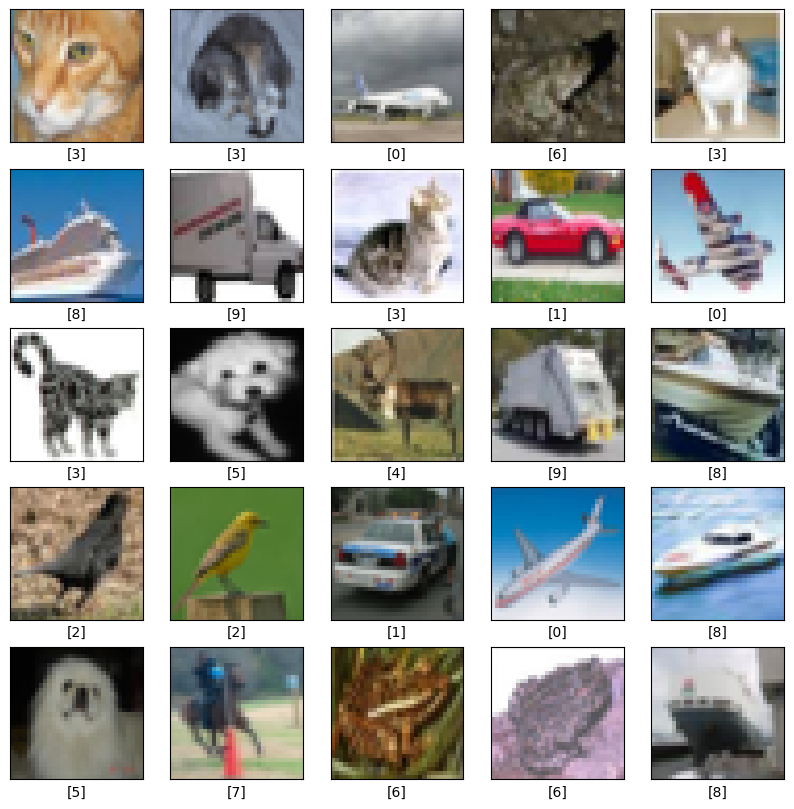

In [6]:
show_random_examples(X_train, y_train)

# Data Preparation

# Task 4: Veri setini standartlaştırınız

# Task 4 Solution

In [7]:
X_train, X_val = X_train / 255.0, X_val / 255.0

# Task 5: Tensorflow Dataset Oluşturunuz

# Task 5 Solution

In [8]:
def prepare_datasets(X_train, X_val, y_train, y_val, batch_size=None):
    if batch_size is None:
        batch_size = len(X_train)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    return train_dataset, val_dataset

In [9]:
train_ds, val_ds = prepare_datasets(X_train, X_val, y_train, y_val, batch_size=32)

# Model

# Task 6: Model yapısını oluşturunuz.

 Model yapısını dilediğiniz gibi oluşturabilirsiniz.

 Ana amacımız yüzde 70 accuracy üzerine çıkmak.

 İstediğiniz sayıda evrişim katmanı (Conv2D) ekleyebilirsiniz.

 Bu katmanlara istediğiniz sayılarda nöron girebilirsiniz.

 Ayrı ayrı 3 tane katman girebilirsiniz ya da blocklar oluşturabilirsiniz yani peş peşe 2 tane evrişim katmanı ekleyip ondan sonra max pooling yapıp sonra peş peşe örneğin 2 tane daha evrişim katmanı ekleyebilirsiniz.

 Tam bağlantılı katmanlarda da istediğiniz gibi deneme-yanılma yapabilirsiniz.

 İstediğiniz herhangi başka katmanları da ekleyebilirsiniz.

 70 üzerine en fazla kimin çıkabileceğini merak ediyorum!



# Task 6 Solution

In [10]:
model = Sequential([
    Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')

])

# Task 7: Modeli Compile ediniz.

# Task 7 Solution

In [11]:
metrics = [
    metrics.SparseCategoricalAccuracy(name="sparse_categorical_accuracy"),

    metrics.AUC(name='auc', multi_label=True)]

In [12]:
model.compile(optimizer='adam',

              loss="sparse_categorical_crossentropy",

              metrics=metrics)



# Task 8: Callback yapılarını tanımlayınız.

# Task 8 Solution

In [13]:
early_stopping = EarlyStopping(monitor='val_loss',
                           patience=20,
                           verbose=1)

model_checkpoint = ModelCheckpoint(filepath='cifar10_model.keras',
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=False,
                             verbose=1)

# Task 9 Solution

In [14]:
history = model.fit(train_ds,
                    epochs=100,
                    validation_data=val_ds,
                    callbacks=[early_stopping, model_checkpoint])

Epoch 1/100
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - auc: 0.5407 - loss: 1.8362 - sparse_categorical_accuracy: 0.3042
Epoch 1: val_loss improved from None to 1.29863, saving model to cifar10_model.keras

Epoch 1: finished saving model to cifar10_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 41ms/step - auc: 0.5361 - loss: 1.6089 - sparse_categorical_accuracy: 0.4022 - val_auc: 0.5317 - val_loss: 1.2986 - val_sparse_categorical_accuracy: 0.5290
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - auc: 0.5211 - loss: 1.2810 - sparse_categorical_accuracy: 0.5389
Epoch 2: val_loss improved from 1.29863 to 1.12378, saving model to cifar10_model.keras

Epoch 2: finished saving model to cifar10_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - auc: 0.5189 - loss: 1.2399 - sparse_categorical_accuracy: 0.5571 - val_auc: 0.5581 - val_loss: 1.1238 - val_sparse_categorical_accuracy: 0.5973
Epoch 3/100
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - auc: 0.5134 - loss: 1.0954 - sp

# Task 10: Model performansını değerlendiriniz

# Task 10 Solution

In [16]:
def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()

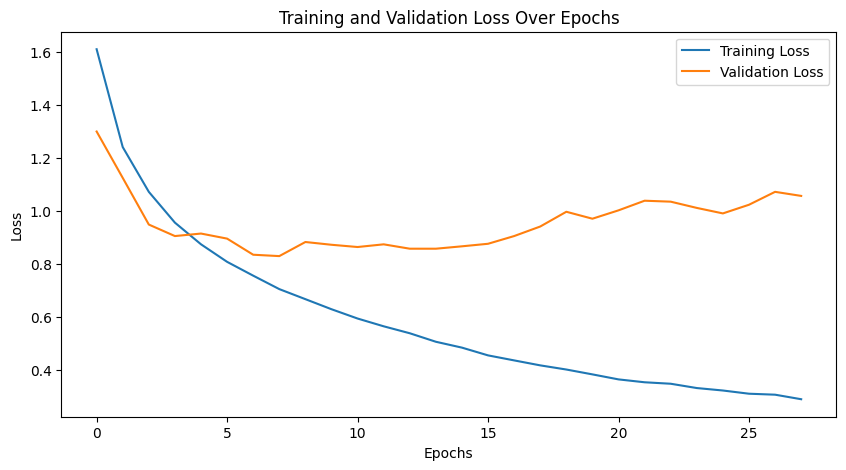

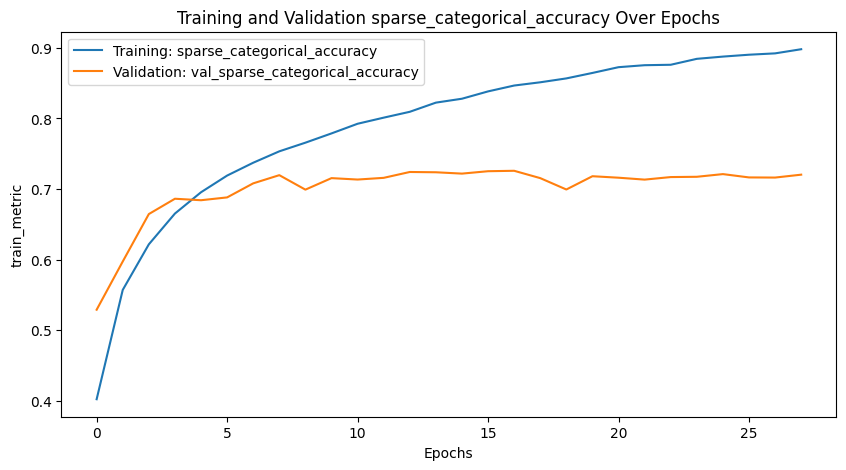

In [17]:

plot_training_history(history, train_loss='loss', train_metric='sparse_categorical_accuracy', val_loss='val_loss', val_metric='val_sparse_categorical_accuracy')




Modelin Öğrenme Eğrisi: Eğitim logları incelendiğinde, modelin 8. Epoch'ta en iyi doğrulama kaybı (val_loss) değerine ulaştığı görülmektedir.

Overfitting (Aşırı Öğrenme) Analizi: 8. Epoch'tan sonra eğitim doğruluğu %90'lara doğru hızla tırmanırken, doğrulama doğruluğu %72 bandında sabit kalmıştır. Bu durum, modelin bu noktadan sonra genelleme yapmak yerine eğitim verisini ezberlemeye (overfitting) başladığını gösterir.

Callback Başarısı: Sistem aşırı öğrenmeyi fark ettiği için Early Stopping mekanizması gereksiz eğitimi durdurmuş ve Model Checkpoint sayesinde modelin en sağlıklı olduğu 8. Epoch'taki ağırlıklar kaydedilmiştir.

Gelecek Çalışmalar: Modelin kapasitesi oldukça yüksek olup, gelecekte aşırı öğrenmeyi kırmak ve doğruluk oranını daha da artırmak için sisteme Data Augmentation (Veri Çoğaltma) katmanları eklenebilir.